In [1]:
import stereo as st
import warnings
warnings.filterwarnings('ignore')

In [2]:
st.__version__

'1.5.1'

In [3]:
data_path = './data/SS200000135TL_D1.tissue.gef'
st.io.read_gef_info(data_path)

[2025-11-18 14:39:10][Stereo][87122][MainThread][47034253847936][reader][1481][INFO]: This is GEF file which contains traditional bin infomation.
[2025-11-18 14:39:10][Stereo][87122][MainThread][47034253847936][reader][1482][INFO]: bin_type: bins
[2025-11-18 14:39:10][Stereo][87122][MainThread][47034253847936][reader][1485][INFO]: Bin size list: ['bin1']
[2025-11-18 14:39:10][Stereo][87122][MainThread][47034253847936][reader][1491][INFO]: Resolution: 500
[2025-11-18 14:39:10][Stereo][87122][MainThread][47034253847936][reader][1494][INFO]: Gene count: 24302
[2025-11-18 14:39:10][Stereo][87122][MainThread][47034253847936][reader][1503][INFO]: offsetX: 0
[2025-11-18 14:39:10][Stereo][87122][MainThread][47034253847936][reader][1506][INFO]: offsetY: 0
[2025-11-18 14:39:10][Stereo][87122][MainThread][47034253847936][reader][1509][INFO]: Width: 26458
[2025-11-18 14:39:10][Stereo][87122][MainThread][47034253847936][reader][1512][INFO]: Height: 26458
[2025-11-18 14:39:10][Stereo][87122][MainThr

{'bin_list': ['bin1'],
 'resolution': 500,
 'gene_count': 24302,
 'offsetX': 0,
 'offsetY': 0,
 'width': 26458,
 'height': 26458,
 'maxExp': 23}

In [4]:
st

<module 'stereo' from '/data01/sunxuebo/software/miniconda3/envs/st/lib/python3.8/site-packages/stereo/__init__.py'>

In [5]:
data = st.io.read_gef(file_path=data_path, bin_size=50)

# simply type the varibale to get related information
data

[2025-11-18 14:39:10][Stereo][87122][MainThread][47034253847936][reader][1303][INFO]: read_gef begin ...


[2025-11-18 14:39:24][Stereo][87122][MainThread][47034253847936][reader][1452][INFO]: the matrix has 35998 cells, and 24302 genes.
[2025-11-18 14:39:24][Stereo][87122][MainThread][47034253847936][reader][1453][INFO]: read_gef end.


StereoExpData object with n_cells X n_genes = 35998 X 24302
bin_type: bins
bin_size: 50
offset_x = 0
offset_y = 0
cells: ['cell_name']
genes: ['gene_name']
cells_matrix = ['spatial']
Layers with keys: 
tl.result: []

In [6]:
data.tl.cal_qc()

[2025-11-18 14:39:24][Stereo][87122][MainThread][47034253847936][st_pipeline][41][INFO]: start to run cal_qc...
[2025-11-18 14:39:25][Stereo][87122][MainThread][47034253847936][st_pipeline][44][INFO]: cal_qc end, consume time 0.6761s.


Column
    [0] Markdown(str)
    [1] Row
        [0] TextInput(name='file name', placeholder='Enter a file name...', width=200)
        [1] Select(name='file format', options=['png', 'pdf'], value='png', width=60)
        [2] IntInput(name='dpi', placeholder='Enter the dip...', start=0, value=100, width=200)
    [2] Row
        [0] Button(button_type='primary', name='export', width=100)
        [1] StaticText(width=800)

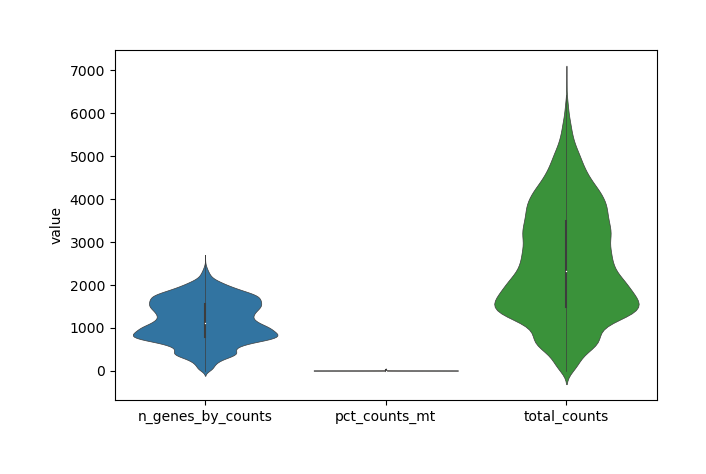

In [7]:
data.plt.violin()

Column
    [0] Markdown(str)
    [1] Row
        [0] TextInput(name='file name', placeholder='Enter a file name...', width=200)
        [1] Select(name='file format', options=['png', 'pdf'], value='png', width=60)
        [2] IntInput(name='dpi', placeholder='Enter the dip...', start=0, value=100, width=200)
    [2] Row
        [0] Button(button_type='primary', name='export', width=100)
        [1] StaticText(width=800)

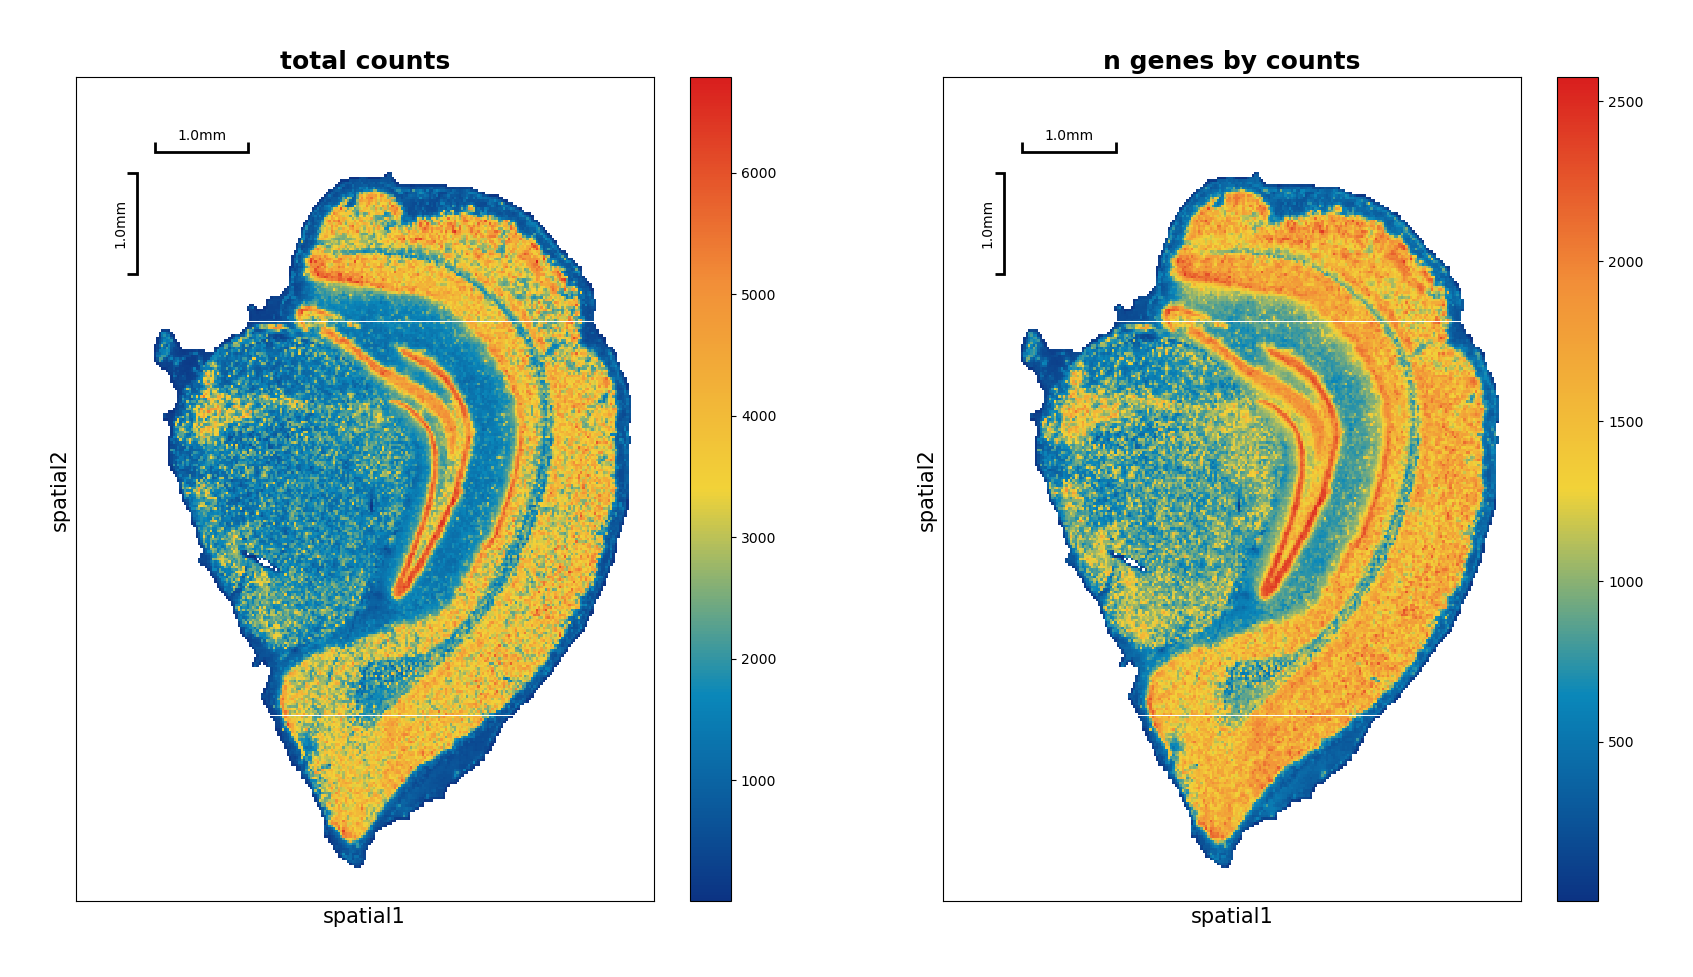

In [8]:
data.plt.spatial_scatter()

Column
    [0] Markdown(str)
    [1] Row
        [0] TextInput(name='file name', placeholder='Enter a file name...', width=200)
        [1] Select(name='file format', options=['png', 'pdf'], value='png', width=60)
        [2] IntInput(name='dpi', placeholder='Enter the dip...', start=0, value=100, width=200)
    [2] Row
        [0] Button(button_type='primary', name='export', width=100)
        [1] StaticText(width=800)

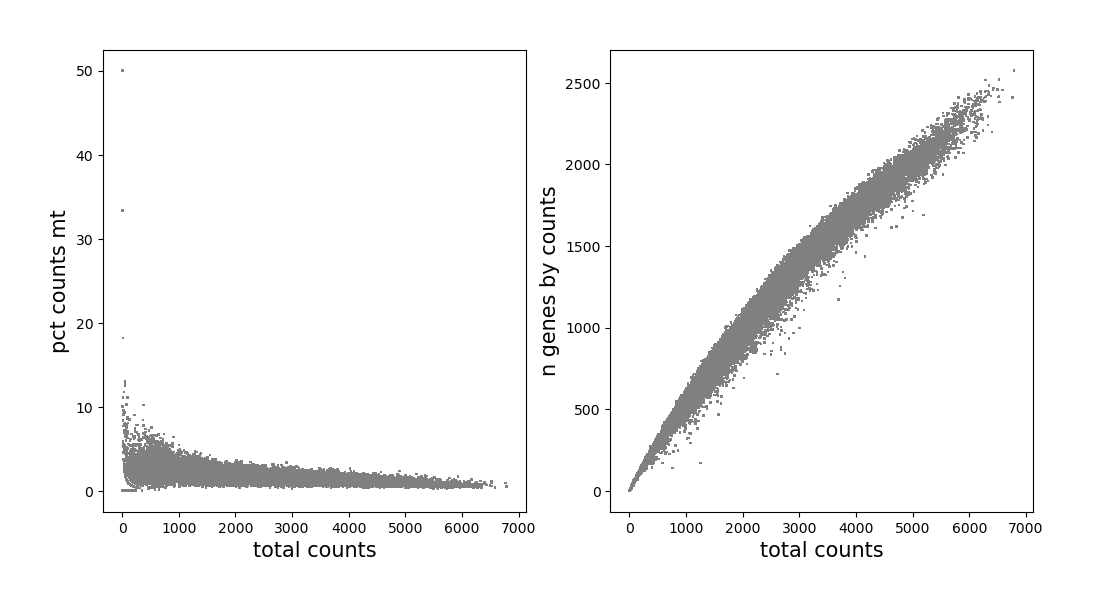

In [9]:
data.plt.genes_count()

In [10]:
data.tl.filter_cells(
        min_counts=20,
        min_genes=3,
        pct_counts_mt=5,
        inplace=True
        )
data


[2025-11-18 14:40:36][Stereo][87122][MainThread][47034253847936][st_pipeline][41][INFO]: start to run filter_cells...
[2025-11-18 14:40:37][Stereo][87122][MainThread][47034253847936][st_pipeline][44][INFO]: filter_cells end, consume time 0.5697s.


StereoExpData object with n_cells X n_genes = 35738 X 24302
bin_type: bins
bin_size: 50
offset_x = 0
offset_y = 0
cells: ['cell_name', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt']
genes: ['gene_name', 'n_cells', 'n_counts', 'mean_umi']
cells_matrix = ['spatial']
Layers with keys: 
tl.result: []

In [11]:
data.tl.raw_checkpoint()

In [12]:
data.tl.raw

StereoExpData object with n_cells X n_genes = 35738 X 24302
bin_type: bins
bin_size: 50
offset_x = 0
offset_y = 0
cells: ['cell_name', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt']
genes: ['gene_name', 'n_cells', 'n_counts', 'mean_umi']
cells_matrix = ['spatial']
Layers with keys: 
tl.result: []

In [13]:
data.tl.normalize_total(target_sum=10000)
data.tl.log1p()

[2025-11-18 14:47:30][Stereo][87122][MainThread][47034253847936][st_pipeline][41][INFO]: start to run normalize_total...
[2025-11-18 14:47:30][Stereo][87122][MainThread][47034253847936][st_pipeline][44][INFO]: normalize_total end, consume time 0.4629s.
[2025-11-18 14:47:30][Stereo][87122][MainThread][47034253847936][st_pipeline][41][INFO]: start to run log1p...
[2025-11-18 14:47:31][Stereo][87122][MainThread][47034253847936][st_pipeline][44][INFO]: log1p end, consume time 0.6046s.


In [14]:
data.tl.highly_variable_genes(
        min_mean=0.0125,
        max_mean=3,
        min_disp=0.5,
        n_top_genes=2000,
        res_key='highly_variable_genes'
        )

[2025-11-18 14:47:52][Stereo][87122][MainThread][47034253847936][st_pipeline][41][INFO]: start to run highly_variable_genes...
[2025-11-18 14:47:55][Stereo][87122][MainThread][47034253847936][st_pipeline][44][INFO]: highly_variable_genes end, consume time 2.7276s.


Column
    [0] Markdown(str)
    [1] Row
        [0] TextInput(name='file name', placeholder='Enter a file name...', width=200)
        [1] Select(name='file format', options=['png', 'pdf'], value='png', width=60)
        [2] IntInput(name='dpi', placeholder='Enter the dip...', start=0, value=100, width=200)
    [2] Row
        [0] Button(button_type='primary', name='export', width=100)
        [1] StaticText(width=800)

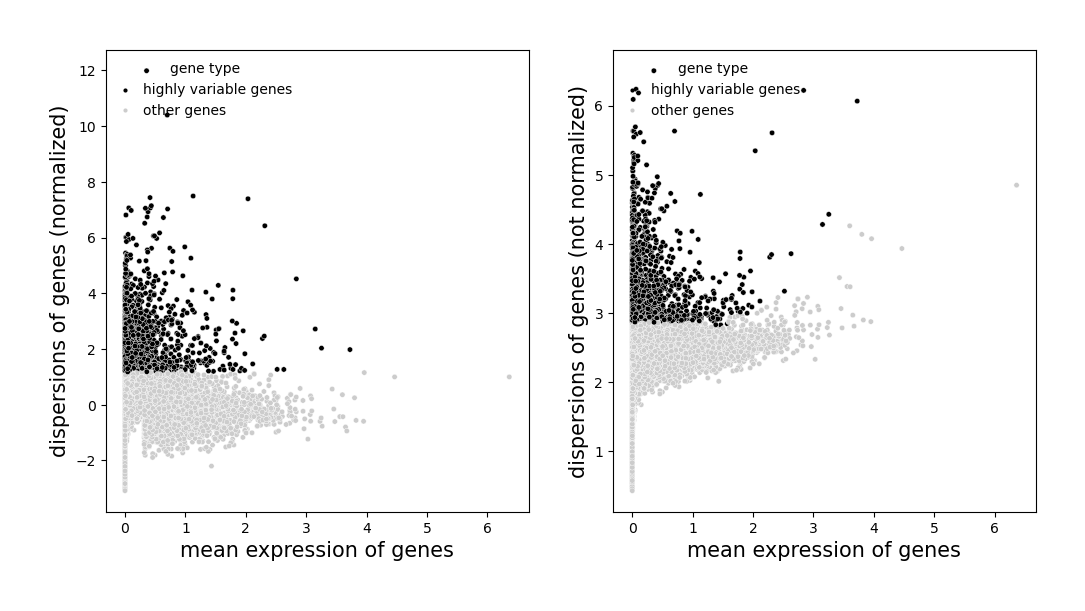

In [15]:
data.plt.highly_variable_genes(res_key='highly_variable_genes')

In [16]:
data.tl.scale(max_value=10, zero_center=True)

[2025-11-18 14:51:54][Stereo][87122][MainThread][47034253847936][st_pipeline][41][INFO]: start to run scale...
[2025-11-18 14:52:00][Stereo][87122][MainThread][47034253847936][scale][53][INFO]: Truncate at max_value 10
[2025-11-18 14:52:01][Stereo][87122][MainThread][47034253847936][st_pipeline][44][INFO]: scale end, consume time 7.6345s.


In [17]:
data.tl.pca(
        use_highly_genes=False,
        n_pcs=30,
        res_key='pca'
        )

[2025-11-18 14:52:06][Stereo][87122][MainThread][47034253847936][st_pipeline][41][INFO]: start to run pca...
[2025-11-18 14:52:24][Stereo][87122][MainThread][47034253847936][st_pipeline][44][INFO]: pca end, consume time 17.9748s.


In [18]:
data.tl.key_record

{'hvg': ['highly_variable_genes'],
 'pca': ['pca'],
 'neighbors': [],
 'umap': [],
 'cluster': [],
 'marker_genes': []}

[2025-11-18 14:52:41][Stereo][87122][MainThread][47034253847936][plot_collection][84][INFO]: register plot_func elbow to <stereo.plots.plot_collection.PlotCollection object at 0x2ac89edab310>


Column
    [0] Markdown(str)
    [1] Row
        [0] TextInput(name='file name', placeholder='Enter a file name...', width=200)
        [1] Select(name='file format', options=['png', 'pdf'], value='png', width=60)
        [2] IntInput(name='dpi', placeholder='Enter the dip...', start=0, value=100, width=200)
    [2] Row
        [0] Button(button_type='primary', name='export', width=100)
        [1] StaticText(width=800)

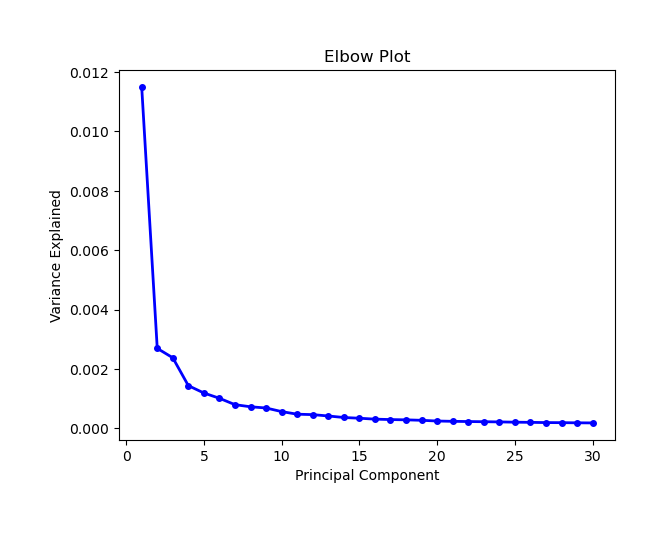

In [19]:
data.plt.elbow(pca_res_key='pca')

In [20]:
data.tl.neighbors(
        pca_res_key='pca',
        n_pcs=30,
        res_key='neighbors'
        )

# compute spatial neighbors
data.tl.spatial_neighbors(
        neighbors_res_key='neighbors',
        res_key='spatial_neighbors'
        )

[2025-11-18 14:53:05][Stereo][87122][MainThread][47034253847936][st_pipeline][41][INFO]: start to run neighbors...
[2025-11-18 14:53:41][Stereo][87122][MainThread][47034253847936][st_pipeline][44][INFO]: neighbors end, consume time 36.2698s.
[2025-11-18 14:53:41][Stereo][87122][MainThread][47034253847936][st_pipeline][41][INFO]: start to run spatial_neighbors...
[2025-11-18 14:53:54][Stereo][87122][MainThread][47034253847936][reader][940][INFO]: Adding sample in adata.obs['orig.ident'].
[2025-11-18 14:53:54][Stereo][87122][MainThread][47034253847936][reader][943][INFO]: Adding data.position as adata.obsm['spatial'] .
[2025-11-18 14:53:54][Stereo][87122][MainThread][47034253847936][reader][948][INFO]: Adding data.position as adata.obs['x'] and adata.obs['y'] .
[2025-11-18 14:53:54][Stereo][87122][MainThread][47034253847936][reader][988][INFO]: Adding data.tl.result['highly_variable_genes'] into adata.var .
[2025-11-18 14:53:54][Stereo][87122][MainThread][47034253847936][reader][1031][IN

In [21]:
data.tl.umap(pca_res_key='pca', neighbors_res_key='neighbors', res_key='umap')

[2025-11-18 14:55:45][Stereo][87122][MainThread][47034253847936][st_pipeline][41][INFO]: start to run umap...


	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs


[2025-11-18 14:56:09][Stereo][87122][MainThread][47034253847936][st_pipeline][44][INFO]: umap end, consume time 23.8778s.


Column
    [0] Markdown(str)
    [1] Row
        [0] TextInput(name='file name', placeholder='Enter a file name...', width=200)
        [1] Select(name='file format', options=['png', 'pdf'], value='png', width=60)
        [2] IntInput(name='dpi', placeholder='Enter the dip...', start=0, value=100, width=200)
    [2] Row
        [0] Button(button_type='primary', name='export', width=100)
        [1] StaticText(width=800)

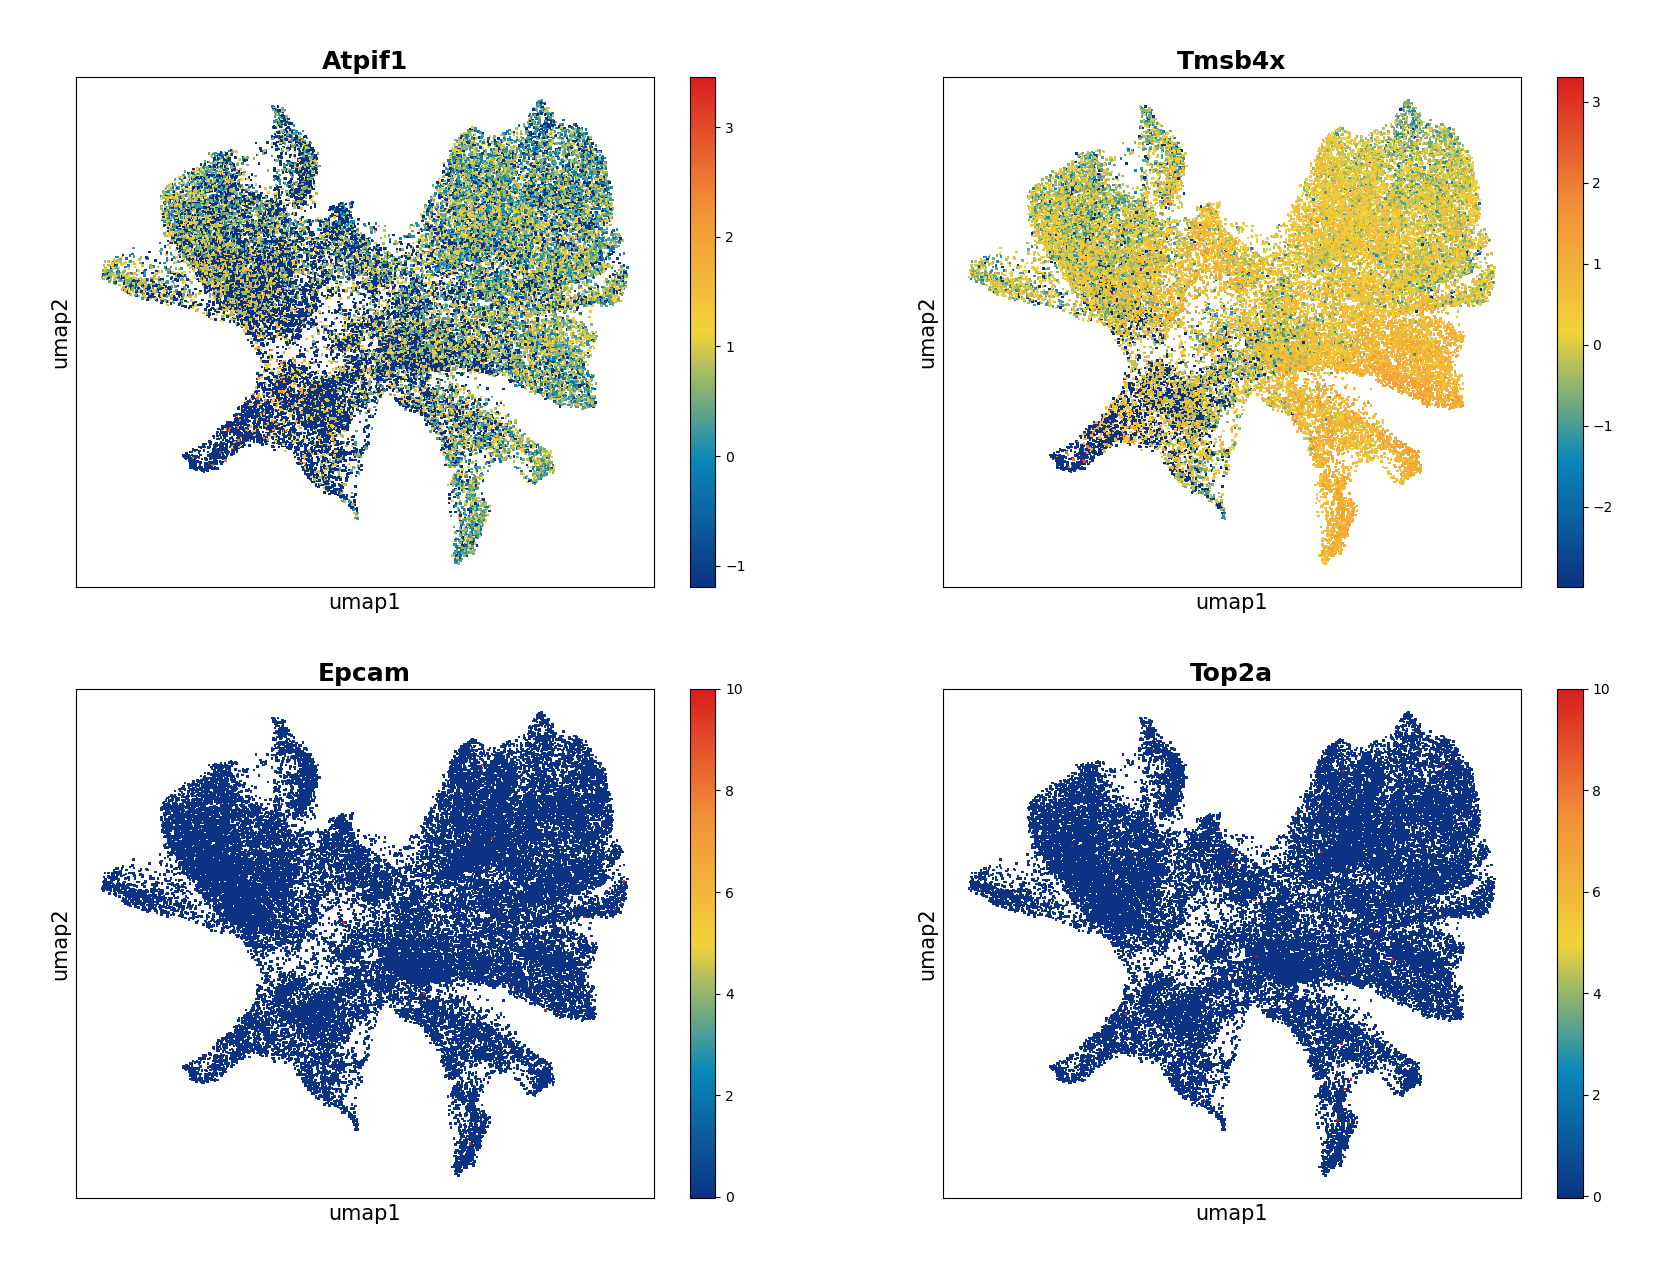

In [23]:
data.plt.umap(gene_names=['Atpif1', 'Tmsb4x','Epcam','Top2a'], res_key='umap')

In [25]:
data.tl.leiden(neighbors_res_key='neighbors', res_key='leiden')

[2025-11-18 14:56:34][Stereo][87122][MainThread][47034253847936][st_pipeline][41][INFO]: start to run leiden...
[2025-11-18 14:56:39][Stereo][87122][MainThread][47034253847936][st_pipeline][44][INFO]: leiden end, consume time 5.3370s.


Column
    [0] Markdown(str)
    [1] Row
        [0] TextInput(name='file name', placeholder='Enter a file name...', width=200)
        [1] Select(name='file format', options=['png', 'pdf'], value='png', width=60)
        [2] IntInput(name='dpi', placeholder='Enter the dip...', start=0, value=100, width=200)
    [2] Row
        [0] Button(button_type='primary', name='export', width=100)
        [1] StaticText(width=800)

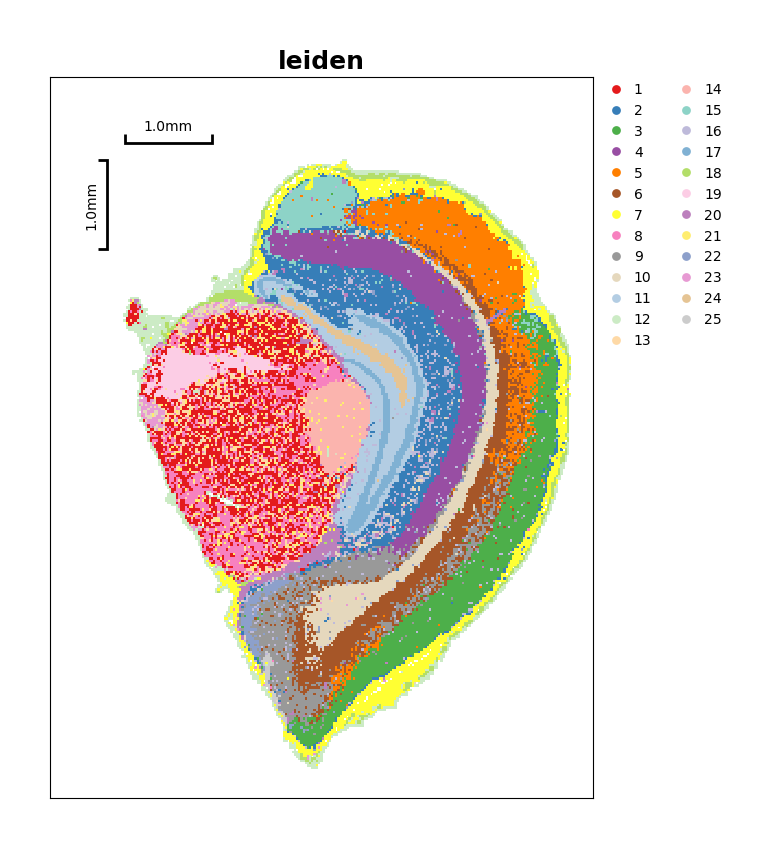

In [26]:
data.plt.cluster_scatter(res_key='leiden')

Column
    [0] Markdown(str)
    [1] Row
        [0] TextInput(name='file name', placeholder='Enter a file name...', width=200)
        [1] Select(name='file format', options=['png', 'pdf'], value='png', width=60)
        [2] IntInput(name='dpi', placeholder='Enter the dip...', start=0, value=100, width=200)
    [2] Row
        [0] Button(button_type='primary', name='export', width=100)
        [1] StaticText(width=800)

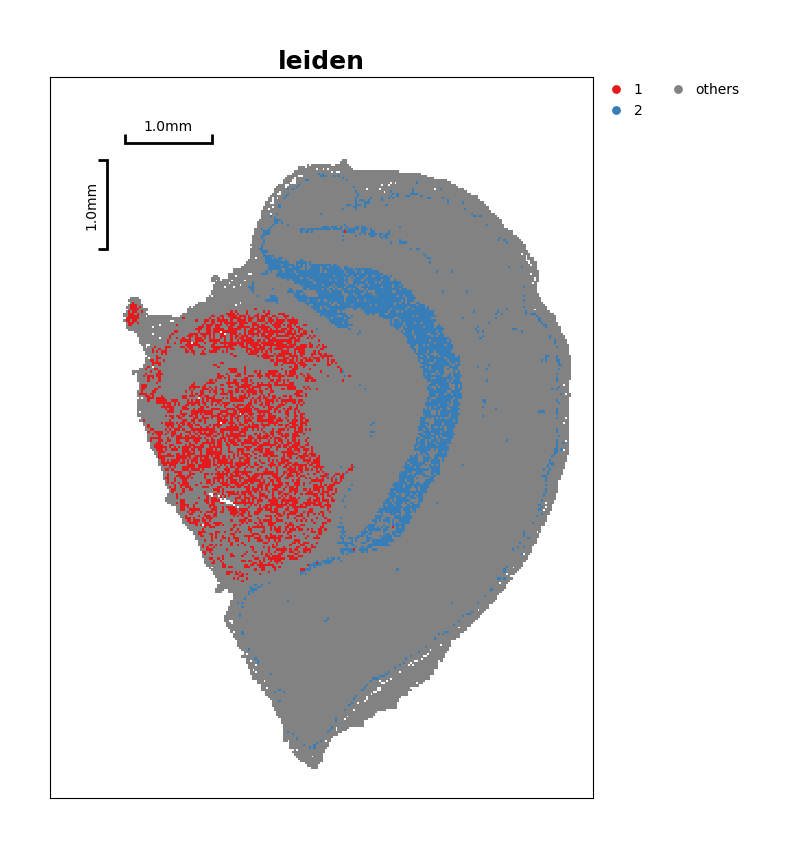

In [27]:
data.plt.cluster_scatter(res_key='leiden', groups=['1', '2'])

In [28]:
data.tl.find_marker_genes(
        cluster_res_key='leiden',
        method='t_test',
        use_highly_genes=False,
        use_raw=True
        )

[2025-11-18 14:57:40][Stereo][87122][MainThread][47034253847936][st_pipeline][41][INFO]: start to run find_marker_genes...
[2025-11-18 14:57:48][Stereo][87122][MainThread][47034253847936][tool_base][122][INFO]: read group information, grouping by group column.
[2025-11-18 14:57:48][Stereo][87122][MainThread][47034253847936][tool_base][151][INFO]: start to run...
[2025-11-18 14:57:56][Stereo][87122][MainThread][47034253847936][tool_base][153][INFO]: end to run.
[2025-11-18 14:57:56][Stereo][87122][MainThread][47034253847936][st_pipeline][44][INFO]: find_marker_genes end, consume time 15.8409s.


Column
    [0] Markdown(str)
    [1] Row
        [0] TextInput(name='file name', placeholder='Enter a file name...', width=200)
        [1] Select(name='file format', options=['png', 'pdf'], value='png', width=60)
        [2] IntInput(name='dpi', placeholder='Enter the dip...', start=0, value=100, width=200)
    [2] Row
        [0] Button(button_type='primary', name='export', width=100)
        [1] StaticText(width=800)

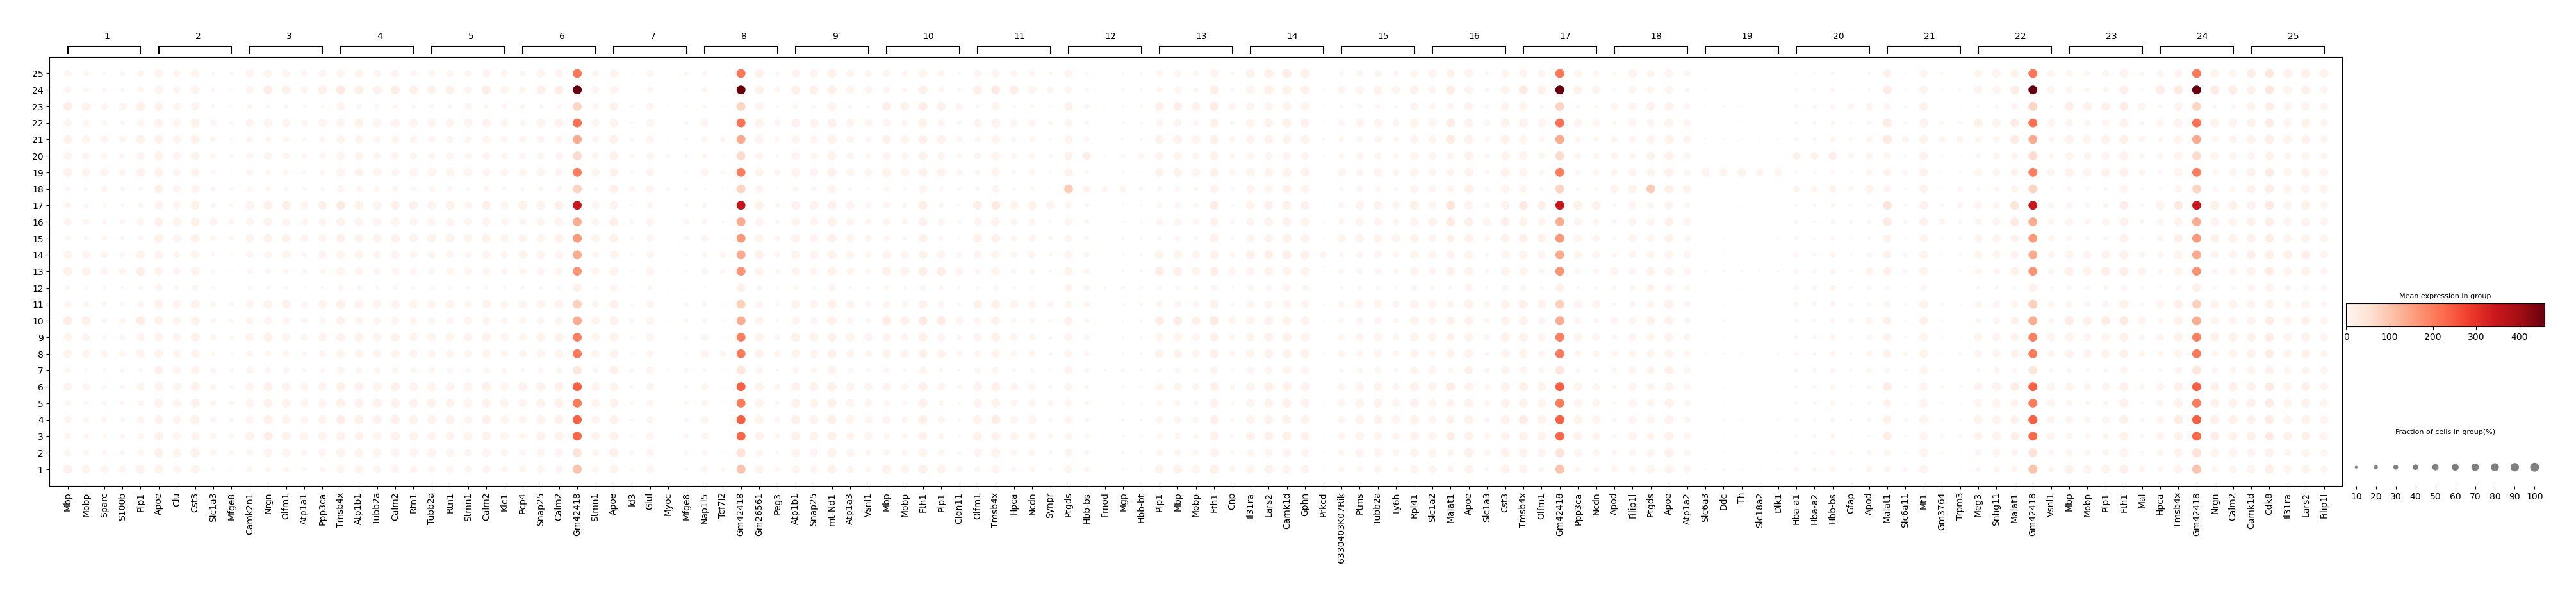

In [29]:
data.plt.marker_genes_scatter(res_key='marker_genes', markers_num=5)

In [31]:
type(data)

stereo.core.stereo_exp_data.StereoExpData

Column
    [0] Markdown(str)
    [1] Row
        [0] TextInput(name='file name', placeholder='Enter a file name...', width=200)
        [1] Select(name='file format', options=['png', 'pdf'], value='png', width=60)
        [2] IntInput(name='dpi', placeholder='Enter the dip...', start=0, value=100, width=200)
    [2] Row
        [0] Button(button_type='primary', name='export', width=100)
        [1] StaticText(width=800)

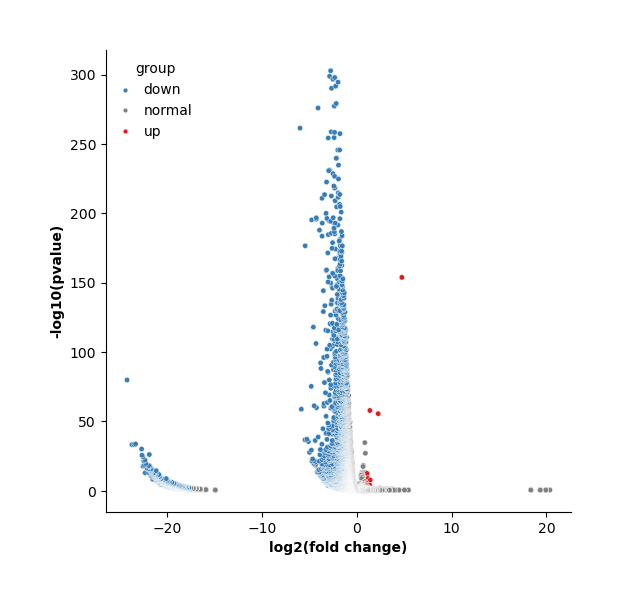

In [32]:
data.plt.marker_gene_volcano(group_name='2.vs.rest', vlines=False)

In [33]:
adata = st.io.stereo_to_anndata(data, output='SS200000135TL_D1_seurat.h5ad')

[2025-11-18 15:00:26][Stereo][87122][MainThread][47034253847936][reader][940][INFO]: Adding sample in adata.obs['orig.ident'].
[2025-11-18 15:00:26][Stereo][87122][MainThread][47034253847936][reader][943][INFO]: Adding data.position as adata.obsm['spatial'] .
[2025-11-18 15:00:26][Stereo][87122][MainThread][47034253847936][reader][948][INFO]: Adding data.position as adata.obs['x'] and adata.obs['y'] .
[2025-11-18 15:00:26][Stereo][87122][MainThread][47034253847936][reader][988][INFO]: Adding data.tl.result['highly_variable_genes'] into adata.var .
[2025-11-18 15:00:26][Stereo][87122][MainThread][47034253847936][reader][1031][INFO]: Adding data.tl.result['pca'] into adata.obsm['X_pca'] .
[2025-11-18 15:00:26][Stereo][87122][MainThread][47034253847936][reader][1036][INFO]: Adding data.tl.result['pca_variance_ratio'] into adata.uns['pca_variance_ratio'] .
[2025-11-18 15:00:26][Stereo][87122][MainThread][47034253847936][reader][1044][INFO]: Adding data.tl.result['neighbors']['connectivitie